In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
!pip show torch

Name: torch
Version: 2.7.1+cu118
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: C:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: torchaudio, torchvision, ultralytics, ultralytics-thop


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pandas matplotlib pillow opencv-python

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
train_dir = r"D:\Downloads\braintumor_dataset\braintumor_dataset\Train"
val_dir   = r"D:\Downloads\braintumor_dataset\braintumor_dataset\Val"
categories = os.listdir(train_dir)
print("Classes:", categories)

Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


Train images


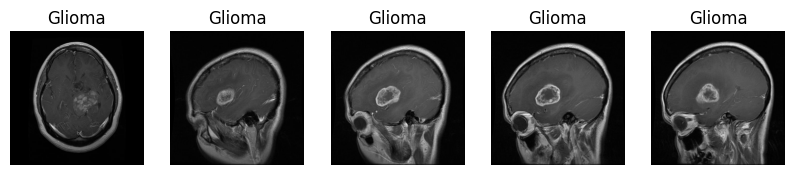

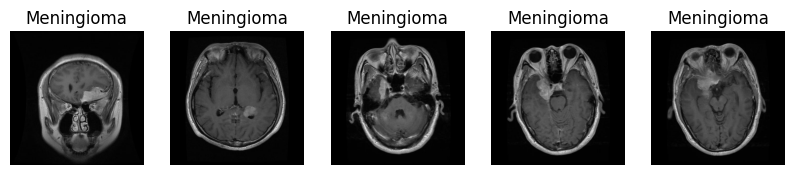

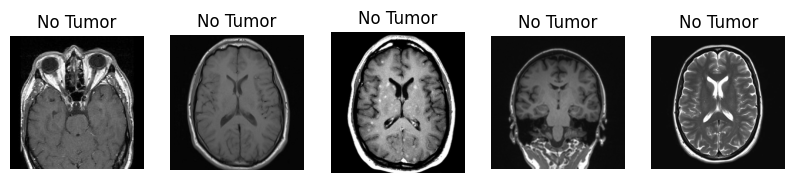

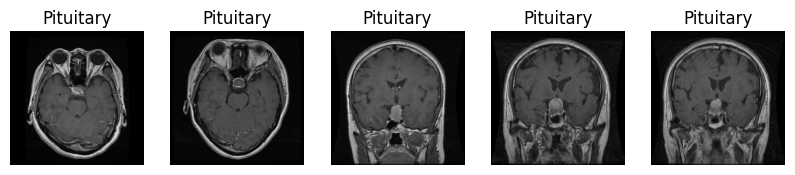

Validation images


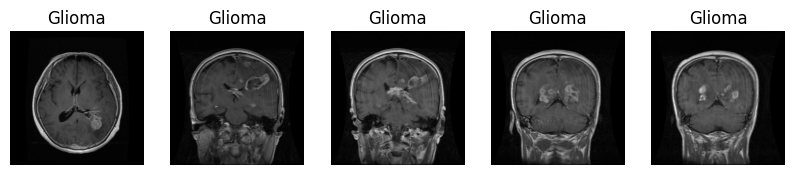

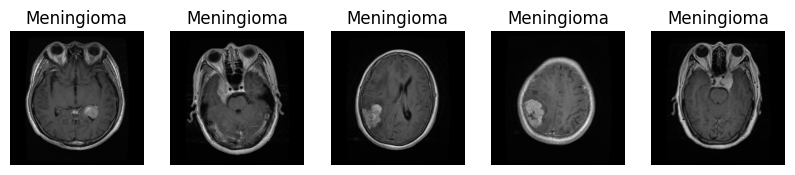

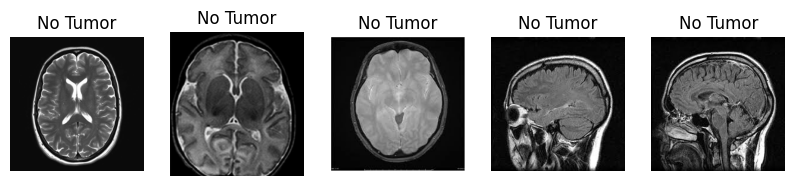

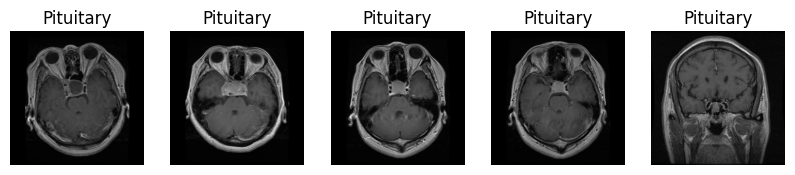

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

classes = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

def sample_images(folder_path, num_samples=5):
    for i in range(4):
        folder_path_final = os.path.join(folder_path, classes[i], 'images')
        images = os.listdir(folder_path_final)
        sample_images = images[:num_samples]

        plt.figure(figsize=(10, 10))
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(folder_path_final, img_name)
            img = cv2.imread(img_path)

            plt.subplot(1, num_samples, j+1)
            plt.imshow(img)
            plt.title(classes[i])
            plt.axis("off")

        plt.show()

print("Train images")
sample_images(train_dir)

print("Validation images")
sample_images(val_dir)


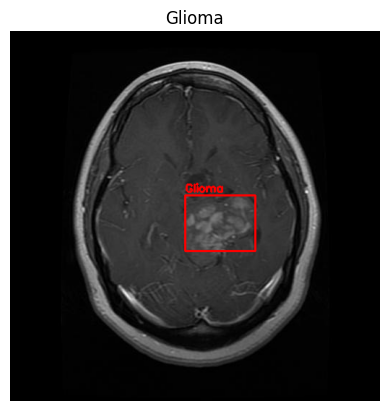

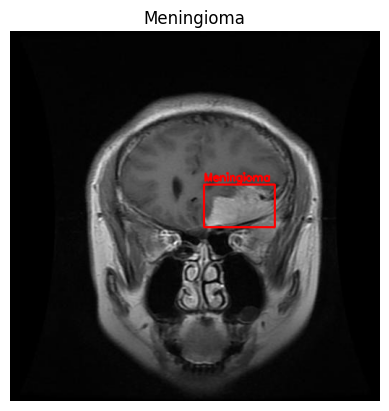

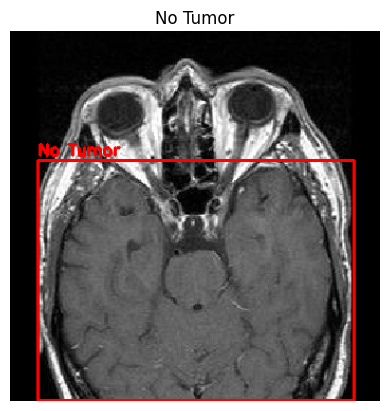

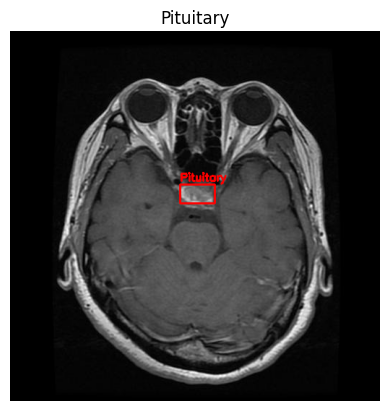

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = r"D:\Downloads\braintumor_dataset\braintumor_dataset\Train"
classes = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

def visualize_bounding_boxes(class_name, img_name):
    img_path = os.path.join(dataset_path, class_name, "images", img_name)
    label_path = os.path.join(dataset_path, class_name, "labels", img_name.replace(".jpg", ".txt"))

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as file:
            lines = file.readlines()

        for line in lines:
            class_id, x_center, y_center, box_width, box_height = map(float, line.split())

            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (255,0,0), 2)
            cv2.putText(image, class_name, (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

    plt.imshow(image)
    plt.axis("off")
    plt.title(class_name)
    plt.show()

for cls in classes:
    sample_img = os.listdir(os.path.join(dataset_path, cls, "images"))[0]
    visualize_bounding_boxes(cls, sample_img)


In [10]:
import os
import shutil

# LOCAL dataset path (change only this)
dataset_path = r"D:\Downloads\braintumor_dataset\braintumor_dataset"

# Output folder (YOLO format)
output_path = r"D:\Downloads\yolo_mri"

for split in ["Train", "Val"]:
    for folder in ["images", "labels"]:
        os.makedirs(os.path.join(output_path, folder, split.lower()), exist_ok=True)

    for tumor_type in ["Glioma", "Meningioma", "No Tumor", "Pituitary"]:
        image_dir = os.path.join(dataset_path, split, tumor_type, "images")
        label_dir = os.path.join(dataset_path, split, tumor_type, "labels")

        for image_name in os.listdir(image_dir):
            if image_name.endswith(".jpg"):
                base = os.path.splitext(image_name)[0]
                label_file = base + ".txt"

                if os.path.exists(os.path.join(label_dir, label_file)):
                    shutil.copy(os.path.join(image_dir, image_name),
                                os.path.join(output_path, "images", split.lower(), image_name))
                    shutil.copy(os.path.join(label_dir, label_file),
                                os.path.join(output_path, "labels", split.lower(), label_file))


In [11]:
yaml_content = """
train: D:\Downloads\braintumor_dataset\braintumor_dataset\Train
val: D:\Downloads\braintumor_dataset\braintumor_dataset\Val

nc: 4
names: ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
"""

with open(r"D:\Downloads\yolo_mri\yolo_mri\data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully (LOCAL)")


data.yaml created successfully (LOCAL)


In [12]:
def count_files(path, ext):
    return len([f for f in os.listdir(path) if f.lower().endswith(ext)])

train_img_path = r"D:\Downloads\yolo_mri\yolo_mri\images\train"
train_lbl_path = r"D:\Downloads\yolo_mri\yolo_mri\labels\train"

print("Training Images:", count_files(train_img_path, (".jpg", ".png", ".jpeg")))
print("Training Labels:", count_files(train_lbl_path, ".txt"))

Training Images: 4737
Training Labels: 4737


In [13]:
def remove_unmatched_images(image_path, label_path):
    image_files = {os.path.splitext(f)[0]
                   for f in os.listdir(image_path)
                   if f.lower().endswith(('.jpg', '.png', '.jpeg'))}

    label_files = {os.path.splitext(f)[0]
                   for f in os.listdir(label_path)
                   if f.endswith('.txt')}

    missing_labels = image_files - label_files

    for img in missing_labels:
        for ext in ['.jpg', '.png', '.jpeg']:
            img_file = os.path.join(image_path, img + ext)
            if os.path.exists(img_file):
                os.remove(img_file)
                print(f"Removed: {img_file}")



In [14]:
!pip install ultralytics


In [15]:
from ultralytics import YOLO

In [17]:
model = YOLO("yolov8s.pt")
model.train(
    data=r"D:\Downloads\yolo_mri\yolo_mri\data.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    workers=4,
    device=0
)


Ultralytics 8.4.37  Python-3.11.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Downloads\yolo_mri\yolo_mri\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001BB45ECE490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

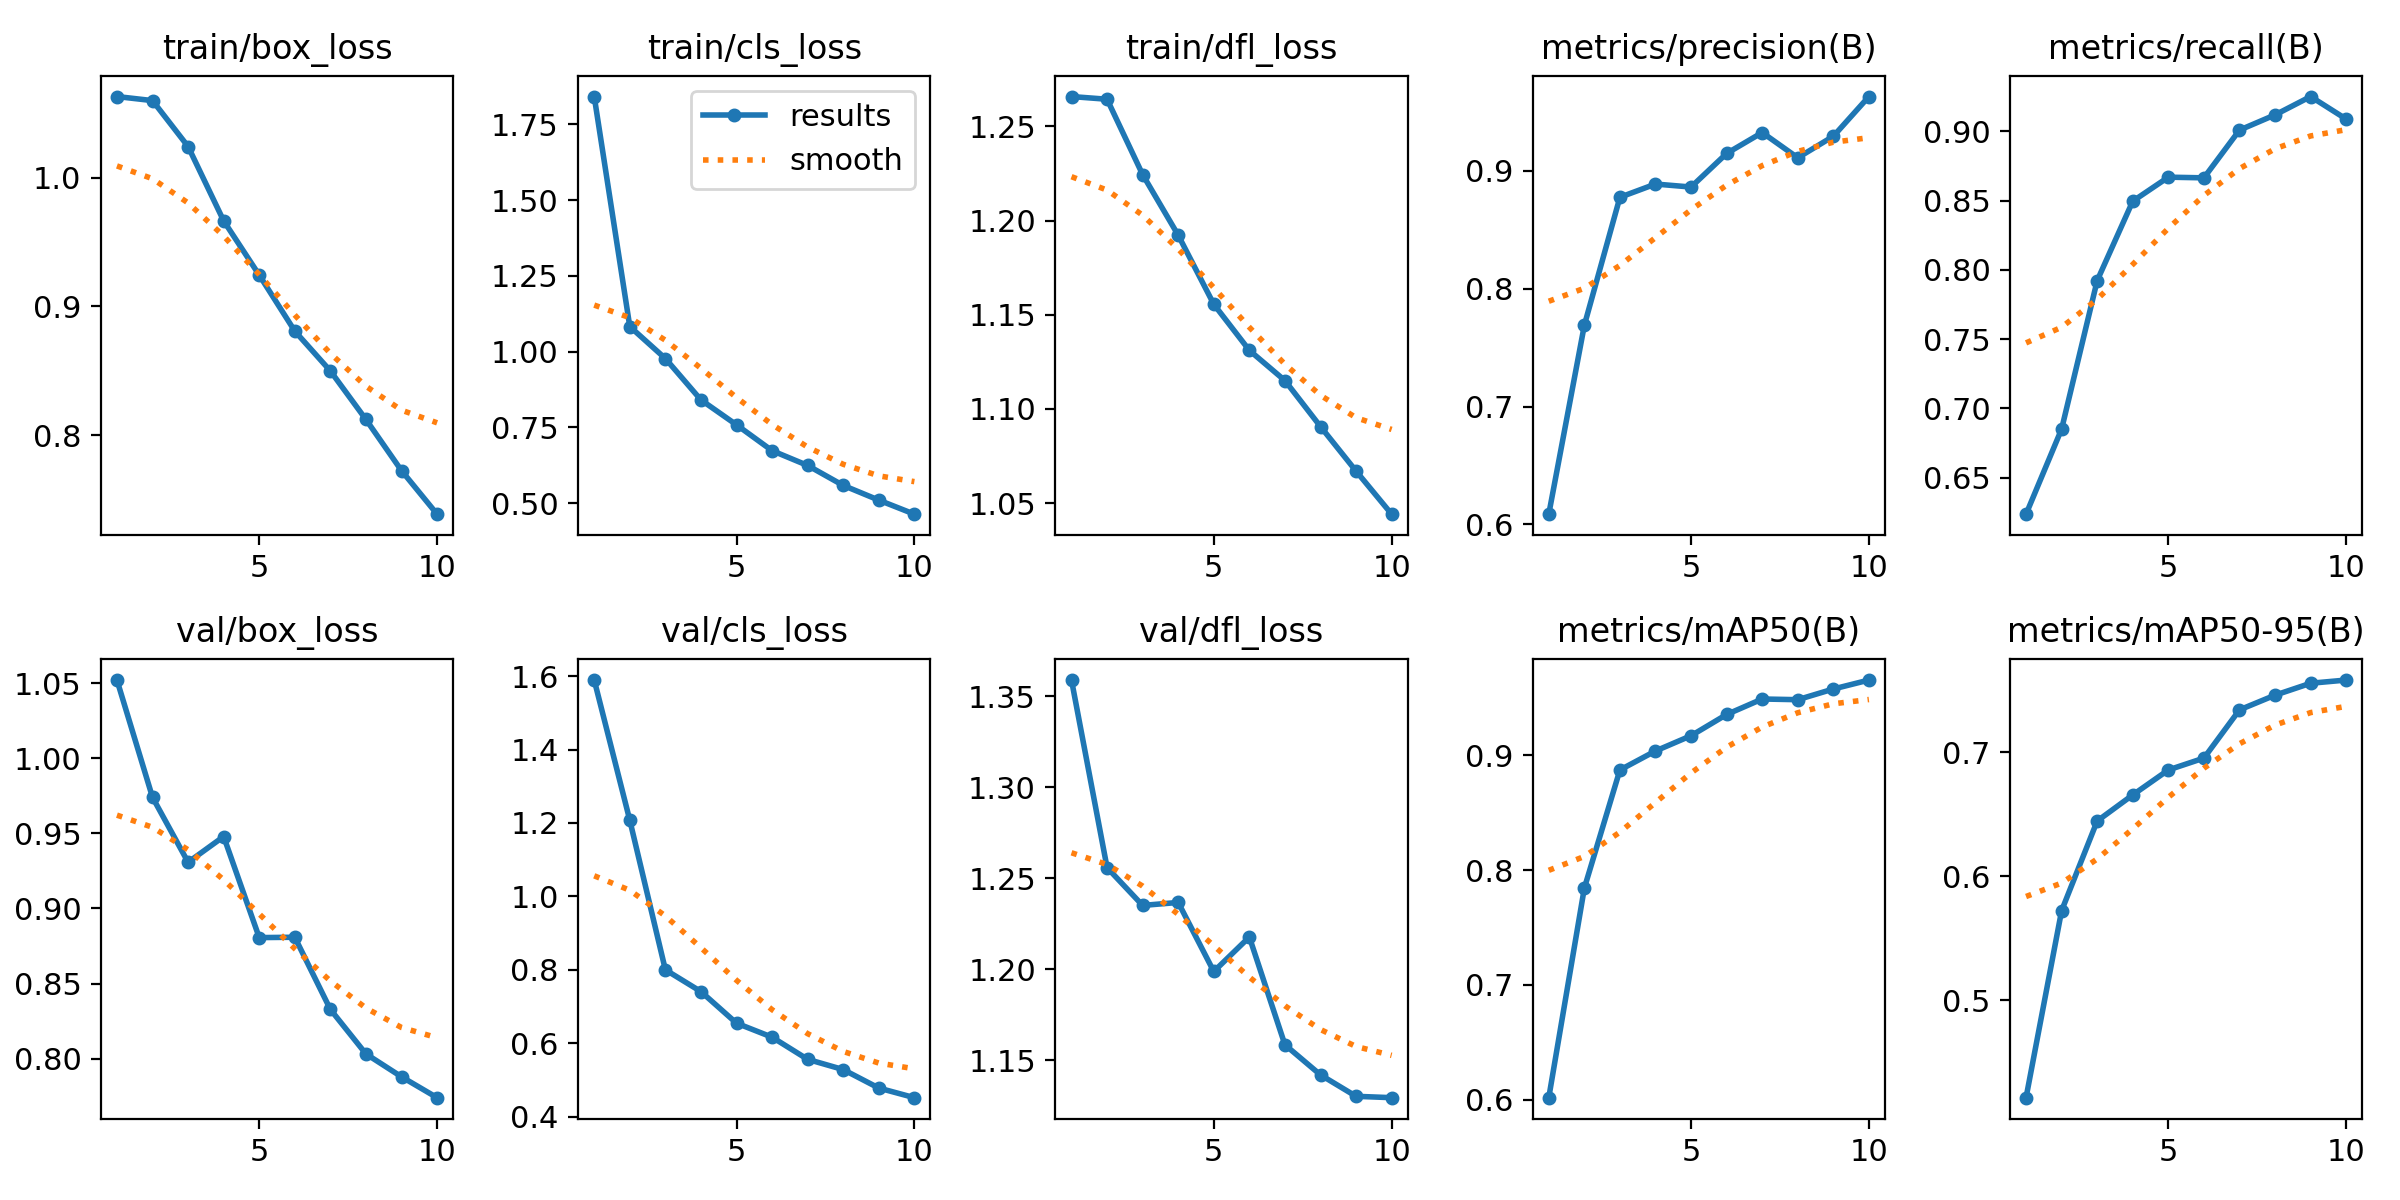

In [23]:
from IPython.display import display, Image

display(Image(filename="runs/detect/train7/results.png"))

In [24]:
import torch

torch.save(model.model.state_dict(),
           r"D:\Downloads\yolo_brain_tumor_model.pth")


In [1]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\adity\runs\detect\train7\weights\best.pt")

In [2]:
metrics = model.val()

Ultralytics 8.4.37  Python-3.11.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.80.2 ms, read: 2.20.9 MB/s, size: 23.1 KB)
val: Scanning D:\Downloads\yolo_mri\labels\val.cache... 510 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 510/510  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.9it/s 10.9s0.3s
                   all        510        554      0.963      0.909      0.965       0.76
                Glioma        135        153      0.957       0.83      0.921      0.727
            Meningioma        140        142      0.976      0.972      0.992      0.797
              No Tumor         98         98          1      0.964      0.994      0.787
             Pituitary        154        161       0.92       0.87      0.954      0.728
Speed: 3.0ms preprocess, 10.4m

In [3]:
metrics = model.val()

precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map95 = metrics.box.map

# Approximate F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Approximate Accuracy (optional for report)
accuracy = (precision + recall) / 2

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Accuracy:", accuracy)
print("mAP50:", map50)
print("mAP50-95:", map95)

Ultralytics 8.4.37  Python-3.11.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 90.846.7 MB/s, size: 23.3 KB)
val: Scanning D:\Downloads\yolo_mri\labels\val.cache... 510 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 510/510  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.9it/s 10.9s0.3s
                   all        510        554      0.963      0.909      0.965       0.76
                Glioma        135        153      0.957       0.83      0.921      0.727
            Meningioma        140        142      0.976      0.972      0.992      0.797
              No Tumor         98         98          1      0.964      0.994      0.787
             Pituitary        154        161       0.92       0.87      0.954      0.728
Speed: 2.5ms preprocess, 9.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to C:\Users\ad

In [4]:
class_names = model.names
ap = metrics.box.ap

for i, name in enumerate(class_names):
    print(name, ap[i])

0 0.7269326401362336
1 0.7967484940424547
2 0.7873760430432568
3 0.7281767081370981


In [5]:
import matplotlib.pyplot as plt

classes = list(model.names.values())
scores = metrics.box.ap

plt.bar(classes, scores)
plt.xlabel("Classes")
plt.ylabel("AP Score")
plt.title("Class-wise Performance")
plt.show()

<Figure size 640x480 with 1 Axes>

In [6]:
model.val(save=True)

Ultralytics 8.4.37  Python-3.11.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 71.514.3 MB/s, size: 25.7 KB)
val: Scanning D:\Downloads\yolo_mri\labels\val.cache... 510 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 510/510  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.0it/s 10.7s0.3s
                   all        510        554      0.963      0.909      0.965       0.76
                Glioma        135        153      0.957       0.83      0.921      0.727
            Meningioma        140        142      0.976      0.972      0.992      0.797
              No Tumor         98         98          1      0.964      0.994      0.787
             Pituitary        154        161       0.92       0.87      0.954      0.728
Speed: 2.3ms preprocess, 10.0ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to C:\Users\a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F6AB4BA8D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [7]:
metrics = model.val()

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.37  Python-3.11.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 50.725.0 MB/s, size: 19.3 KB)
val: Scanning D:\Downloads\yolo_mri\labels\val.cache... 510 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 510/510  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.0it/s 10.6s0.3s
                   all        510        554      0.963      0.909      0.965       0.76
                Glioma        135        153      0.957       0.83      0.921      0.727
            Meningioma        140        142      0.976      0.972      0.992      0.797
              No Tumor         98         98          1      0.964      0.994      0.787
             Pituitary        154        161       0.92       0.87      0.954      0.728
Speed: 2.3ms preprocess, 9.9ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to C:\Users\ad

In [8]:
f1 = 2*(metrics.box.mp * metrics.box.mr)/(metrics.box.mp + metrics.box.mr)
accuracy = (metrics.box.mp + metrics.box.mr)/2

In [9]:
for i, name in enumerate(model.names.values()):
    print(name, metrics.box.ap[i])

Glioma 0.7269326401362336
Meningioma 0.7967484940424547
No Tumor 0.7873760430432568
Pituitary 0.7281767081370981
